# Análisis descriptivo básico del dataset de maquinas de costura

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [258]:
df = pd.read_parquet('../Dataset limpiado/dataset unificado.parquet')

In [259]:
df.shape

(140602, 23)

In [260]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,equipment,6661,int64,"[100268, 100312, 100884, 101632, 101638, 10172..."
1,operation,59,category,"[BIND LEG, BARTACK, SET SLEEVE, TOP STITCH HOO..."
2,wo_type,7,category,"[Corrective Maintenance, Breakdown, Preventati..."
3,base_model,119,category,"[VF2500, LT2-B872, W664, EX5214, VG2700, DLN54..."
4,problem_desc,24,category,"[It sews with defect / Cose con defecto, It do..."
5,failure_desc,38,category,[Machine head failure stopping sewing / Falla...
6,cause_desc,280,category,[Misadjusted machine head teeth / Dientes de c...
7,action_desc,278,category,[Adjust machine head teeth / Ajustar dientes d...
8,mechanic,185,category,"[Jaime Rivera, JERONIMO FUNEZ, Fabit Aranda, C..."
9,date,501,datetime64[ns],"[2023-10-03 00:00:00, 2024-01-17 00:00:00, 202..."


### Número de fallas por modelo base de la máquina: **base_model**.

In [261]:
df_base_model = pd.DataFrame(df['base_model'].value_counts())
print('Número de modelos base de la máquina', len(df_base_model))

Número de modelos base de la máquina 123


### Top 20 modelos base con más frecuencia de fallos

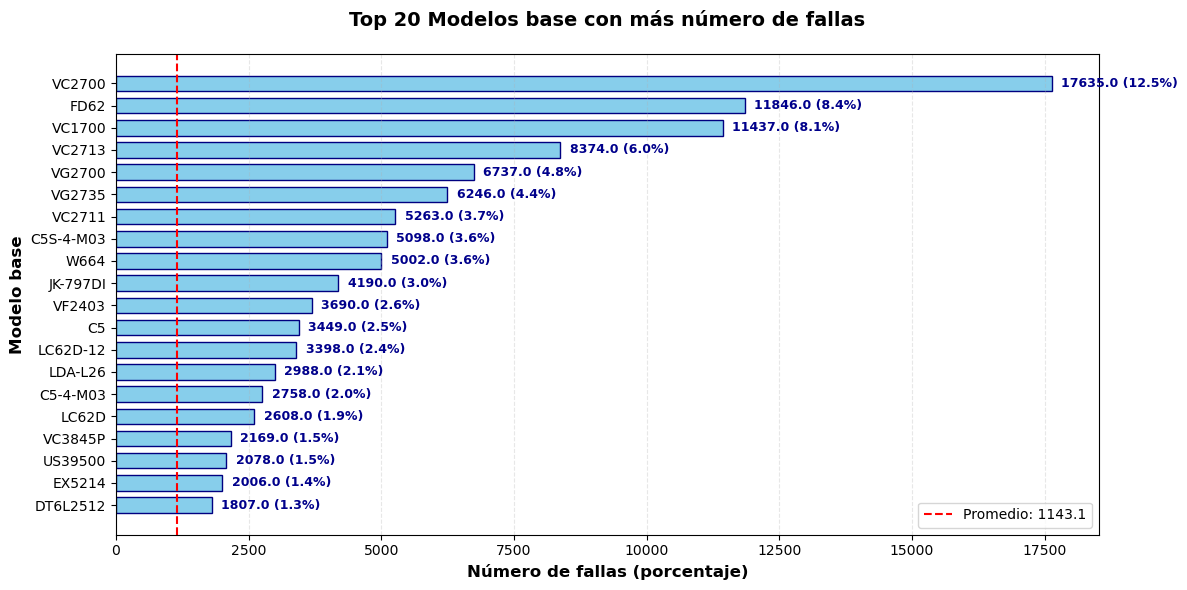


📊 ESTADÍSTICAS DE MODELOS BASE:
Total de modelos base: 123
Total de eventos: 140602
Modelos base más frecuente: VC2700 (17635 eventos)
Modelos base menos frecuente: CW522AN (0 eventos)

Top 5 modelos por frecuencia:
            count  percentage
base_model                   
VC2700      17635        12.5
FD62        11846         8.4
VC1700      11437         8.1
VC2713       8374         6.0
VG2700       6737         4.8


In [262]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_base_model['percentage'] = (df_base_model['count'] / df_base_model['count'].sum() * 100).round(1)
df_base_model['cum_percentage'] = df_base_model['percentage'].cumsum()

# Ordenar
df_sorted = df_base_model.sort_values(by='count', ascending=False)
df_top20 = df_sorted.head(20).sort_values(by='count', ascending=True)

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12,6))

# Barras horizontales
bars = ax1.barh(df_top20.index, df_top20['count'], color='skyblue', edgecolor='navy', height=0.7)

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_top20.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Número de fallas (porcentaje)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Modelo base', fontsize=12, fontweight='bold')
ax1.set_title('Top 20 Modelos base con más número de fallas', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar línea de promedio (opcional)
avg_count = df_sorted['count'].mean()
ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=1, 
            label=f'Promedio: {avg_count:.1f}')
ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE MODELOS BASE:")
print(f"Total de modelos base: {len(df_base_model)}")
print(f"Total de eventos: {df_base_model['count'].sum()}")
print(f"Modelos base más frecuente: {df_base_model['count'].idxmax()} ({df_base_model['count'].max()} eventos)")
print(f"Modelos base menos frecuente: {df_base_model['count'].idxmin()} ({df_base_model['count'].min()} eventos)")
print(f"\nTop 5 modelos por frecuencia:")
print(df_base_model.nlargest(5, 'count')[['count', 'percentage']])

### Todos los modelos base

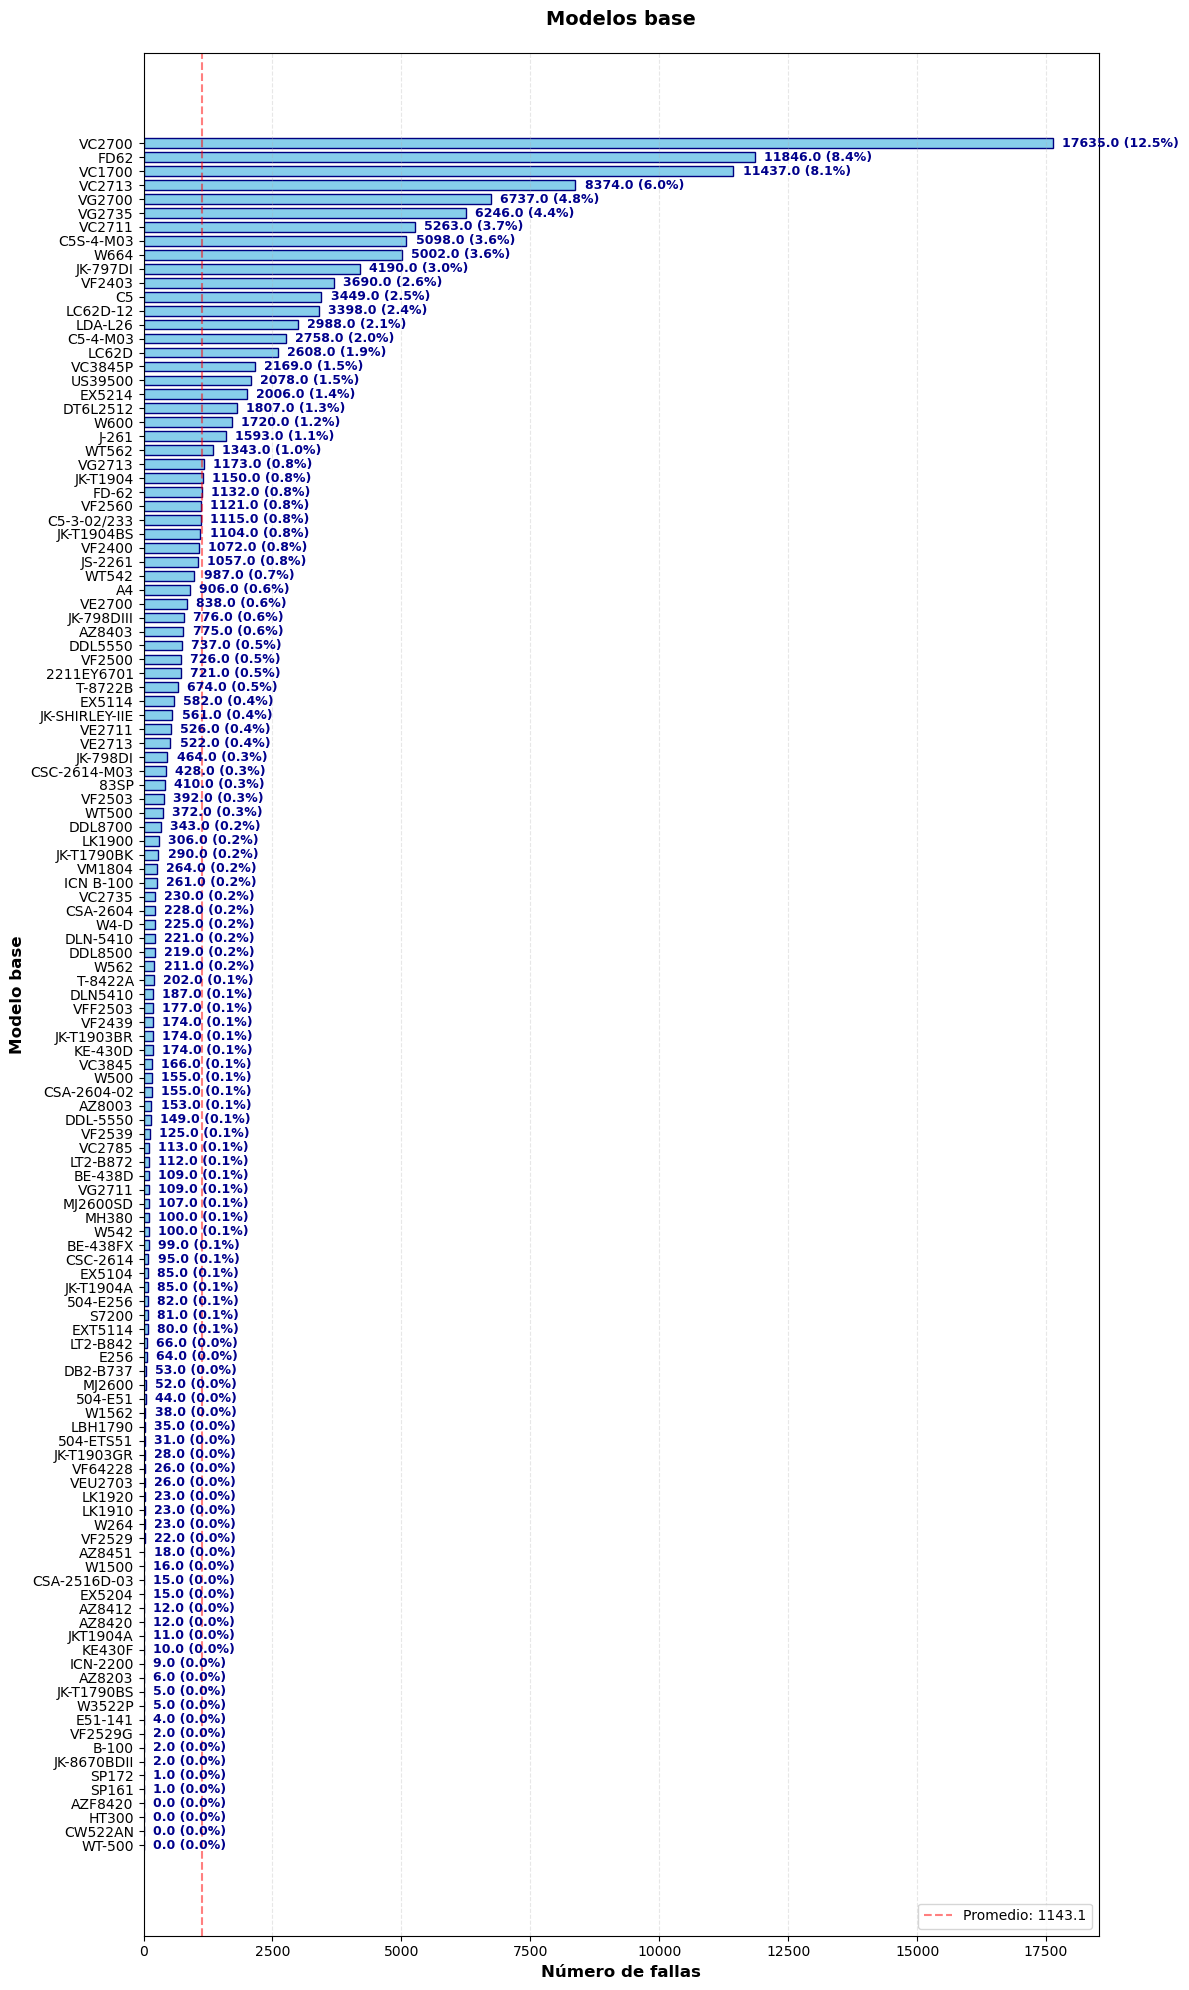


📊 ESTADÍSTICAS DE MODELOS BASE:
Total de modelos base: 123
Total de eventos: 140602
Modelo base más frecuente: VC2700 (17635 eventos)
Modelo base menos frecuente: CW522AN (0 eventos)

Top 5 opermodelos baseaciones por frecuencia:
            count  percentage
base_model                   
VC2700      17635        12.5
FD62        11846         8.4
VC1700      11437         8.1
VC2713       8374         6.0
VG2700       6737         4.8


In [263]:
# Calcular porcentaje acumulado para línea de Pareto
df_base_model['percentage'] = (df_base_model['count'] / df_base_model['count'].sum() * 100).round(1)
df_base_model['cum_percentage'] = df_base_model['percentage'].cumsum()

# Ordenar
df_sorted = df_base_model.sort_values(by='count')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 20))

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['count'], color='skyblue', edgecolor='navy', height=0.7)

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Número de fallas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Modelo base', fontsize=12, fontweight='bold')
ax1.set_title('Modelos base', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar línea de promedio (opcional)
avg_count = df_sorted['count'].mean()
ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
            label=f'Promedio: {avg_count:.1f}')
ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE MODELOS BASE:")
print(f"Total de modelos base: {len(df_base_model)}")
print(f"Total de eventos: {df_base_model['count'].sum()}")
print(f"Modelo base más frecuente: {df_base_model['count'].idxmax()} ({df_base_model['count'].max()} eventos)")
print(f"Modelo base menos frecuente: {df_base_model['count'].idxmin()} ({df_base_model['count'].min()} eventos)")
print(f"\nTop 5 opermodelos baseaciones por frecuencia:")
print(df_base_model.nlargest(5, 'count')[['count', 'percentage']])

### Número de fallas por **wo_type** tipo de orden de trabajo.

In [264]:
df_wo_type = pd.DataFrame(df['wo_type'].value_counts())
df_wo_type

,count
wo_type,
Corrective Maintenance,129918
Breakdown,6152
Calibration,2326
Refurbish Work Order,998
Standard Work Order,802
Preventative Maintenance,390
General Work Order,16


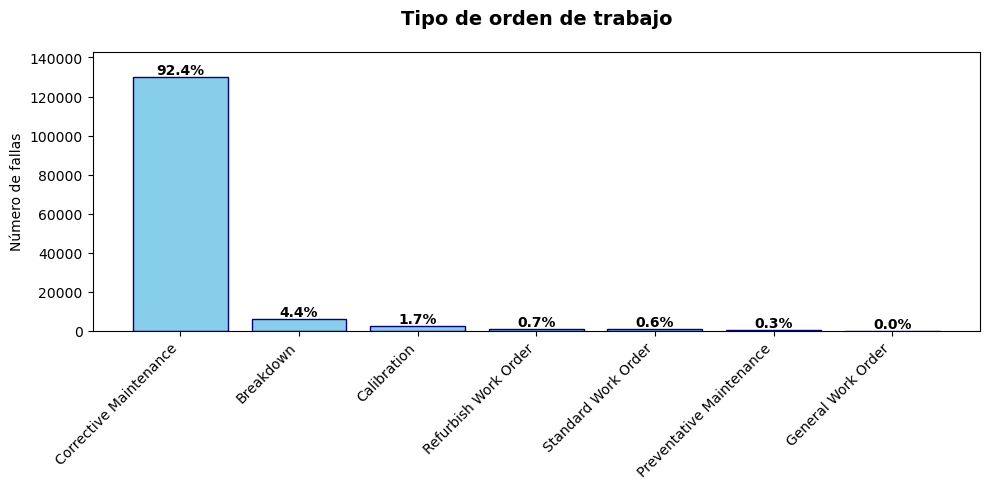

In [265]:
# Calcular porcentaje acumulado para línea de Pareto
df_wo_type['percentage'] = (df_wo_type['count'] / df_wo_type['count'].sum() * 100).round(1)
df_wo_type['cum_percentage'] = df_wo_type['percentage'].cumsum()

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

# Barras horizontales
bars = ax1.bar(df_wo_type.index, df_wo_type['count'], color='skyblue', edgecolor='navy')


# Añadir etiquetas de texto
for i, bar in enumerate(bars):
    count = df_wo_type['count'].iloc[i]
    pct = df_wo_type['percentage'].iloc[i]
    
    # x = posición de la barra, y = altura de la barra + un pequeño margen
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{pct}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ajustar el límite de Y para que las etiquetas no se corten
ax1.set_ylim(0, df_wo_type['count'].max() * 1.1)
# Personalización
ax1.set_xlabel('')
ax1.set_ylabel('Número de fallas')
plt.xticks(rotation=45, ha='right') 
ax1.set_title('Tipo de orden de trabajo', 
              fontsize=14, fontweight='bold', pad=20)


plt.tight_layout()
plt.show()

#### Mantenimiento correctivo - 92.4% !!!<br>Mantenimiento preventivo solo 0.3%

### Frecuencia de fallas por día, semana o mes

#### Por dia

In [266]:
df_fallos_por_dia = df.groupby(['dia'])['downtime_gross'].agg(['count', 'sum'])

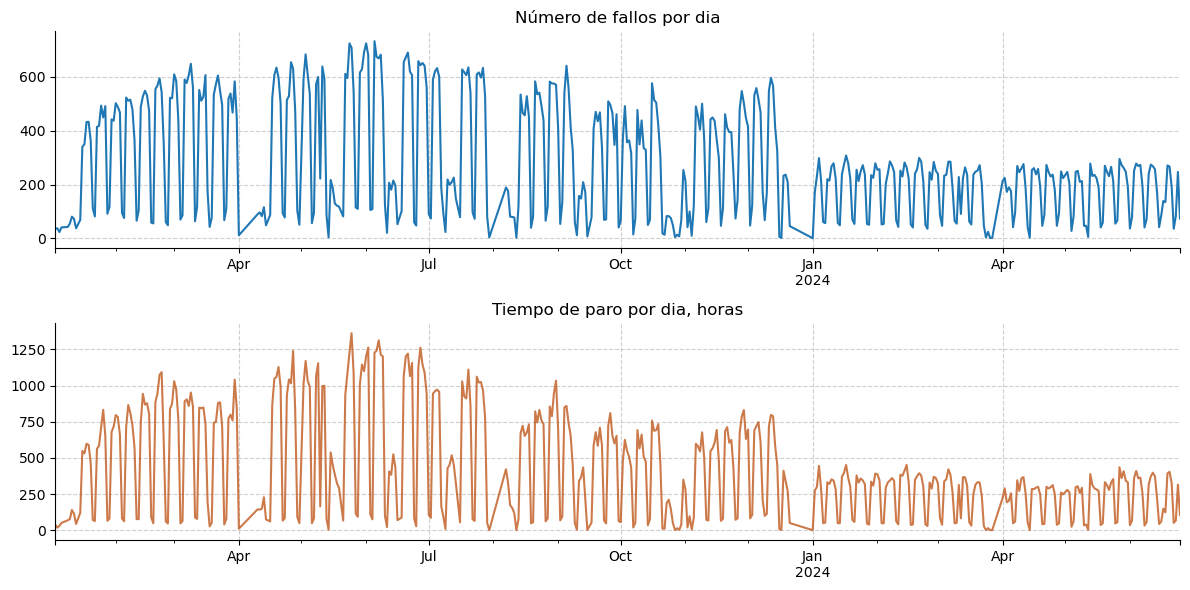

In [267]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Subplot Número de fallos por mes
df_fallos_por_dia.plot.line(y='count', ax=ax1, title='Número de fallos por dia', legend=False)
# for idx, row in df_fallos_por_dia.iterrows():
#     ax1.annotate(str(int(row['count'])), 
#                 xy=(idx, row['count']),  # Usar i como posición x
#                 xytext=(0, 7),
#                 textcoords='offset points',
#                 ha='left', 
#                 fontsize=8)
ax1.set_xlabel('')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Subplot Tiempo de paro por mes
df_fallos_por_dia.plot.line(y='sum', ax=ax2, title='Tiempo de paro por dia, horas', legend=False, color = "#c05619c8")
# for idx, row in df_fallos_por_dia.iterrows():
#     ax2.annotate(str(int(row['sum'])), 
#                 xy=(idx, row['sum']),  # Usar i como posición x
#                 xytext=(0, 7),
#                 textcoords='offset points',
#                 ha='left', 
#                 fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlabel('')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustar el espacio para que no se solapen
plt.tight_layout()
plt.show()

#### Por semana.

In [268]:
df_fallos_por_semana = df.groupby(['semana'])['downtime_gross'].agg(['count', 'sum'])

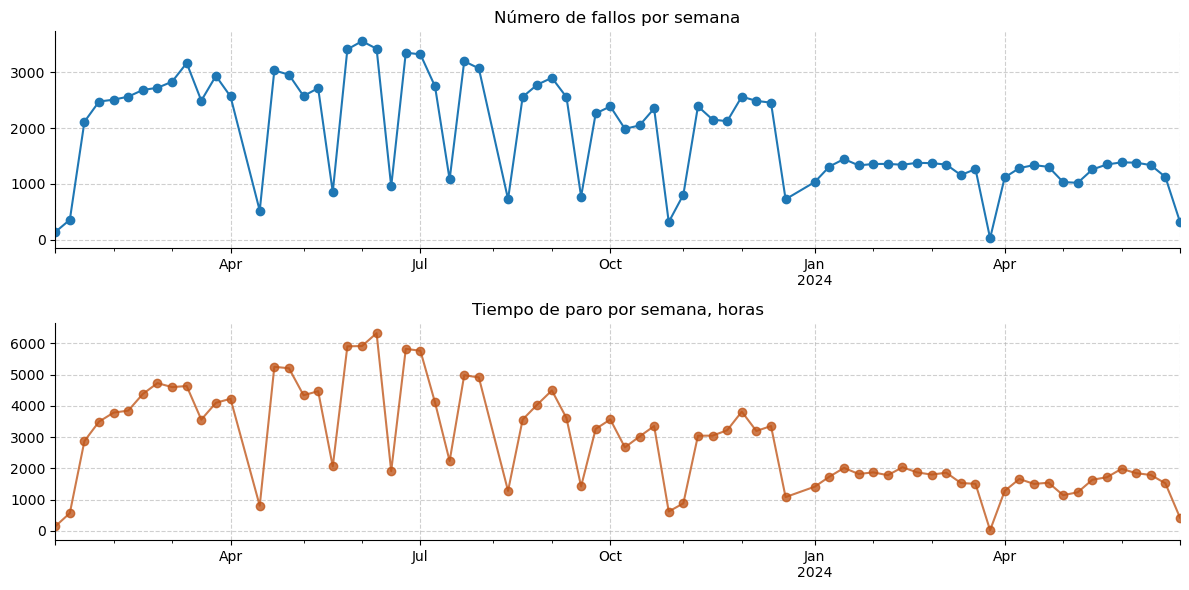

In [269]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Subplot Número de fallos por mes
df_fallos_por_semana.plot.line(y='count', ax=ax1, title='Número de fallos por semana', legend=False, marker='o')
# for idx, row in df_fallos_por_semana.iterrows():
#     ax1.annotate(str(int(row['count'])), 
#                 xy=(idx, row['count']),  # Usar i como posición x
#                 xytext=(0, 7),
#                 textcoords='offset points',
#                 ha='left', 
#                 fontsize=8)
ax1.set_xlabel('')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Subplot Tiempo de paro por mes
df_fallos_por_semana.plot.line(y='sum', ax=ax2, title='Tiempo de paro por semana, horas', legend=False,  marker='o', color = "#c05619c8")
# for idx, row in df_fallos_por_semana.iterrows():
#     ax2.annotate(str(int(row['sum'])), 
#                 xy=(idx, row['sum']),  # Usar i como posición x
#                 xytext=(0, 7),
#                 textcoords='offset points',
#                 ha='left', 
#                 fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlabel('')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustar el espacio para que no se solapen
plt.tight_layout()
plt.show()

#### Por mes.

In [270]:
df_fallos_por_mes = df.groupby(['mes'])['downtime_gross'].agg(['count', 'sum'])

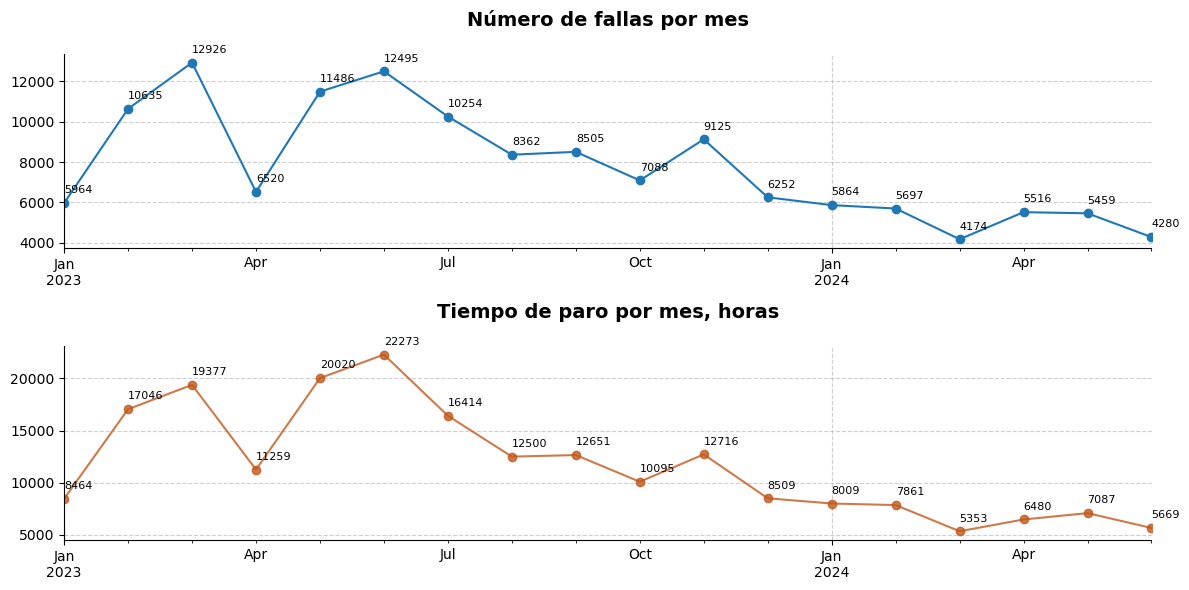

In [298]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Subplot Número de fallos por mes
df_fallos_por_mes.plot.line(y='count', ax=ax1, legend=False, marker='o')
for idx, row in df_fallos_por_mes.iterrows():
    ax1.annotate(str(int(row['count'])), 
                xy=(idx, row['count']),  # Usar i como posición x
                xytext=(0, 7),
                textcoords='offset points',
                ha='left', 
                fontsize=8)
ax1.set_title('Número de fallas por mes', pad=20, fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Subplot Tiempo de paro por mes
df_fallos_por_mes.plot.line(y='sum', ax=ax2, legend=False,  marker='o', color = "#c05619c8")
for idx, row in df_fallos_por_mes.iterrows():
    ax2.annotate(str(int(row['sum'])), 
                xy=(idx, row['sum']),  # Usar i como posición x
                xytext=(0, 7),
                textcoords='offset points',
                ha='left', 
                fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_title('Tiempo de paro por mes, horas', pad=20, fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustar el espacio para que no se solapen
plt.tight_layout()
plt.show()

### Tiempo promedio entre fallas

In [272]:
df_medio_tiempo_de_paro_mes = df.groupby(['mes'])['days_between_failures'].agg(['mean'])
df_medio_tiempo_de_paro_mes.head(3)

,mean
mes,
2023-01,1.428739
2023-02,3.488481
2023-03,5.289649


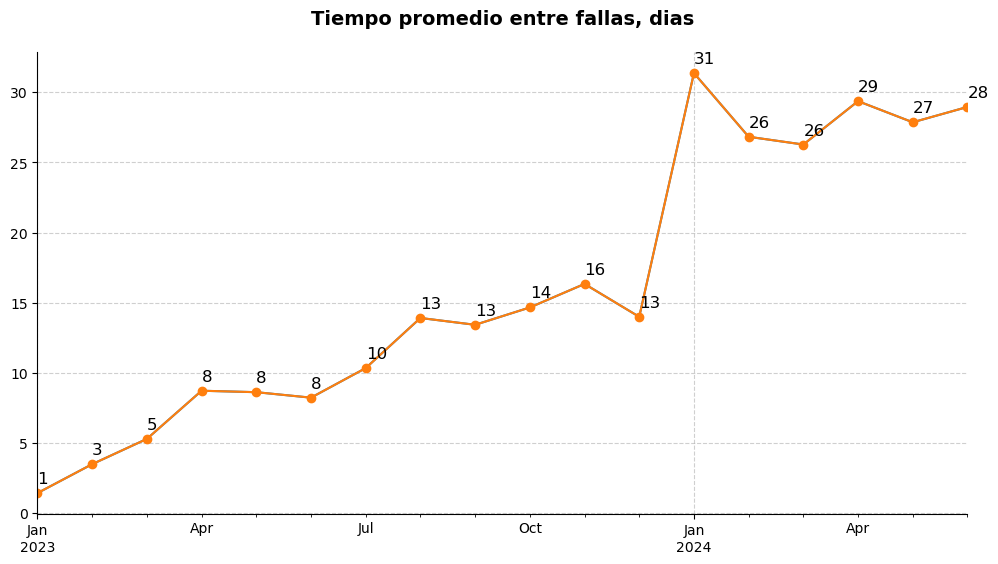

In [300]:
ax = df_medio_tiempo_de_paro_mes.plot.line(figsize=(12,6))

df_medio_tiempo_de_paro_mes.plot.line(y='mean', ax=ax, legend=False, marker='o')
for idx, row in df_medio_tiempo_de_paro_mes.iterrows():
    ax.annotate(str(int(row['mean'])), 
                xy=(idx, row['mean']),  # Usar i como posición x
                xytext=(0, 7),
                textcoords='offset points',
                ha='left', 
                fontsize=12)
    
ax.set_xlabel('')
ax.set_title('Tiempo promedio entre fallas, dias', pad=20, fontsize=14, fontweight='bold')
ax.legend().remove()
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### Tiempo promedio de reparación

In [274]:
df_medio_tiempo_de_reparacion_mes = df.groupby(['mes'])['repair_hours'].agg(['mean'])
df_medio_tiempo_de_reparacion_mes['mean'] = df_medio_tiempo_de_reparacion_mes['mean'] * 60
df_medio_tiempo_de_reparacion_mes.head(3)

,mean
mes,
2023-01,56.844064
2023-02,59.850964
2023-03,56.501083


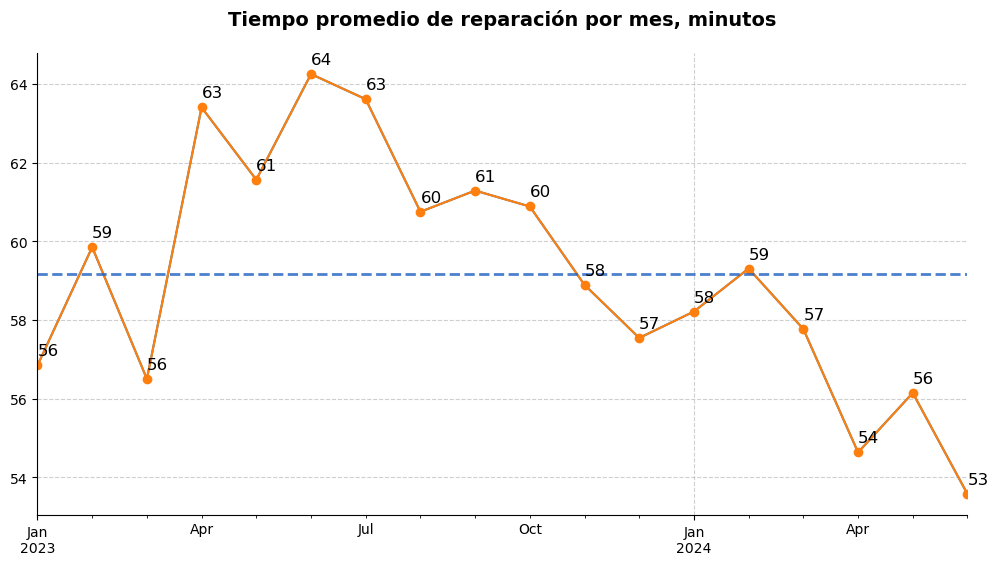

In [301]:
ax = df_medio_tiempo_de_reparacion_mes.plot.line(figsize=(12,6))

df_medio_tiempo_de_reparacion_mes.plot.line(y='mean', ax=ax, legend=False, marker='o')
for idx, row in df_medio_tiempo_de_reparacion_mes.iterrows():
    ax.annotate(str(int(row['mean'])), 
                xy=(idx, row['mean']),  # Usar i como posición x
                xytext=(0, 7),
                textcoords='offset points',
                ha='left', 
                fontsize=12)
    
# Media global
media_global = df_medio_tiempo_de_reparacion_mes['mean'].mean()

# Línea horizontal de media
ax.axhline(
    y=media_global,
    color = "#195cc0c7",
    linestyle='--',
    linewidth=2,
    label=f"Media global: {media_global:.1f}"
)
    
ax.set_xlabel('')
ax.set_title('Tiempo promedio de reparación por mes, minutos', pad=20, fontsize=14, fontweight='bold')
ax.legend().remove()
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### Variable **mechanic**

In [276]:
df_mecanico = pd.DataFrame(df['mechanic'].value_counts())
df_mecanico.shape

(185, 1)

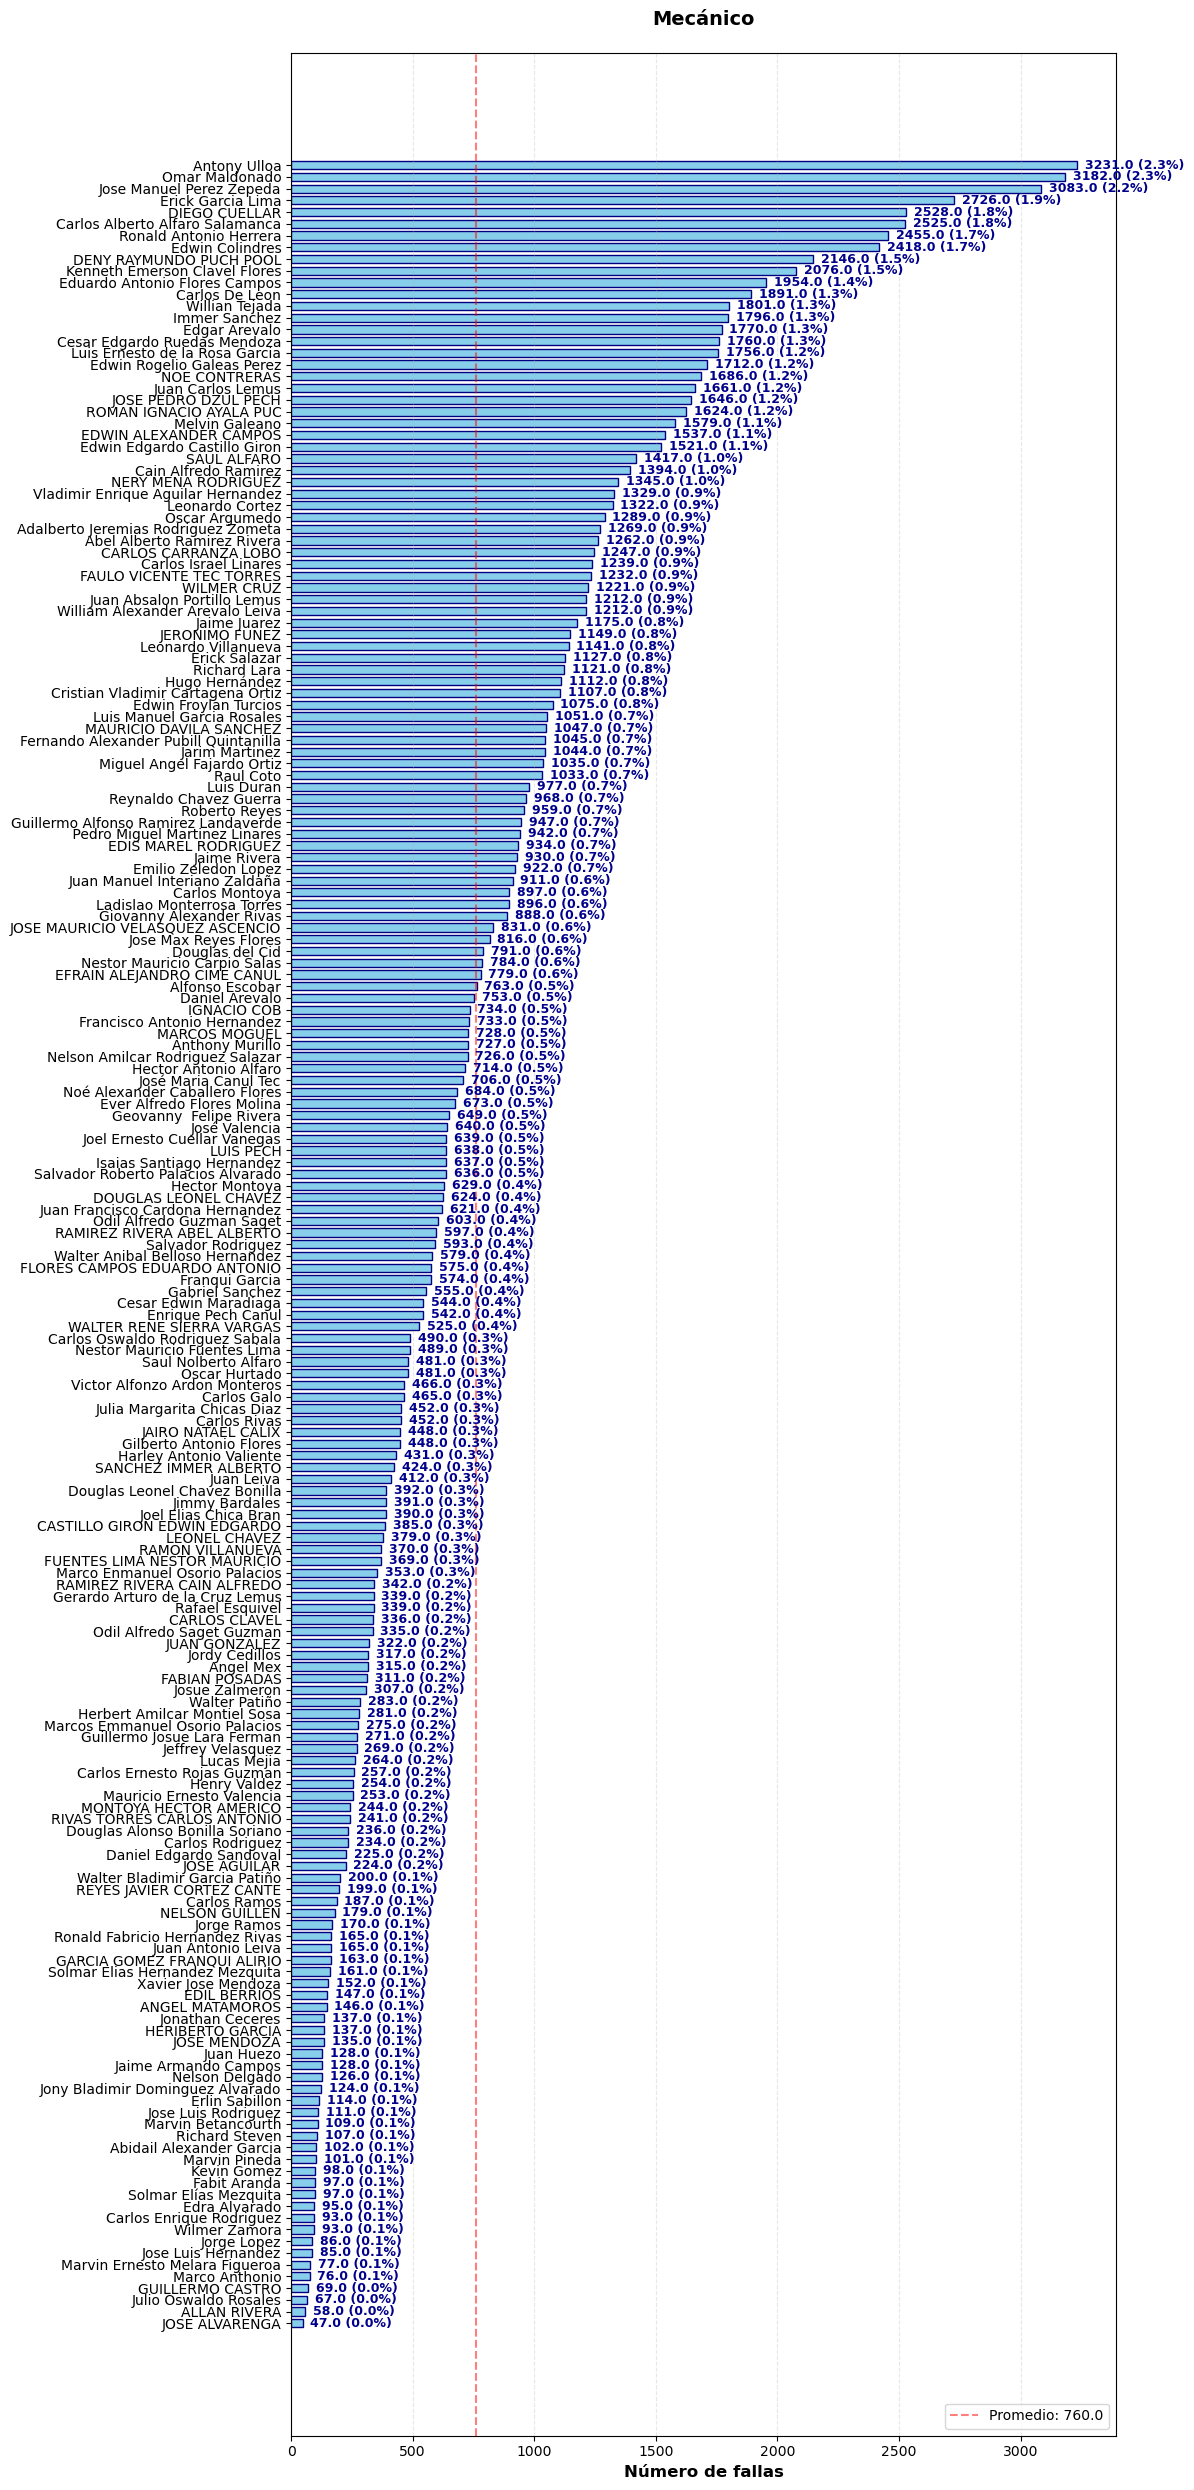


📊 ESTADÍSTICAS DE MODELOS BASE:
Total de modelos base: 185
Total de eventos: 140602
Modelo base más frecuente: Antony Ulloa (3231 eventos)
Modelo base menos frecuente: JOSE ALVARENGA (47 eventos)

Top 5 opermodelos baseaciones por frecuencia:
                          count  percentage
mechanic                                   
Antony Ulloa               3231         2.3
Omar Maldonado             3182         2.3
Jose Manuel Perez Zepeda   3083         2.2
Erick Garcia Lima          2726         1.9
DIEGO CUELLAR              2528         1.8


In [277]:
# Calcular porcentaje acumulado para línea de Pareto
df_mecanico['percentage'] = (df_mecanico['count'] / df_mecanico['count'].sum() * 100).round(1)
df_mecanico['cum_percentage'] = df_mecanico['percentage'].cumsum()

# Ordenar
df_sorted = df_mecanico.sort_values(by='count')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 25))

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['count'], color='skyblue', edgecolor='navy', height=0.7)

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Número de fallas', fontsize=12, fontweight='bold')
ax1.set_ylabel('')
ax1.set_title('Mecánico', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar línea de promedio (opcional)
avg_count = df_sorted['count'].mean()
ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
            label=f'Promedio: {avg_count:.1f}')
ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE MODELOS BASE:")
print(f"Total de modelos base: {len(df_mecanico)}")
print(f"Total de eventos: {df_mecanico['count'].sum()}")
print(f"Modelo base más frecuente: {df_mecanico['count'].idxmax()} ({df_mecanico['count'].max()} eventos)")
print(f"Modelo base menos frecuente: {df_mecanico['count'].idxmin()} ({df_mecanico['count'].min()} eventos)")
print(f"\nTop 5 opermodelos baseaciones por frecuencia:")
print(df_mecanico.nlargest(5, 'count')[['count', 'percentage']])

### Antüedad del mecánico vs media tiempo entre fallas

In [278]:
df_mecanicos_dbfailure = df.groupby('mechanic').agg(
    antiquity = ('antiquity', 'max'), 
    num_fallas = ('mechanic', 'count'),         
    downtime_gross = ('downtime_gross', 'sum'),
    real_downtime = ('real_downtime', 'sum'),
    repair_hours = ('repair_hours', 'sum'),                          
    days_between_failures = ('days_between_failures', 'mean'), 
)
df_mecanicos_dbfailure

,antiquity,num_fallas,downtime_gross,real_downtime,repair_hours,days_between_failures
mechanic,,,,,,
Pedro Miguel Martinez Linares,4.4,942,2428.350000,1451.600000,1381.950000,2.606157
ALLAN RIVERA,18.0,58,25.400000,25.400000,24.383333,15.637931
ANGEL MATAMOROS,18.0,146,62.733333,62.733333,60.066667,27.821918
Abel Alberto Ramirez Rivera,10.0,1262,2640.766667,608.056667,1341.533333,11.692552
Abidail Alexander Garcia,1.0,102,187.333333,35.493333,172.750000,3.000000
...,...,...,...,...,...,...
Walter Patiño,7.6,283,181.916667,38.916667,161.566667,13.279152
William Alexander Arevalo Leiva,5.0,1212,2214.383333,975.743333,1550.716667,5.069307
Willian Tejada,6.0,1801,3084.766667,3084.766667,3067.883333,16.398667


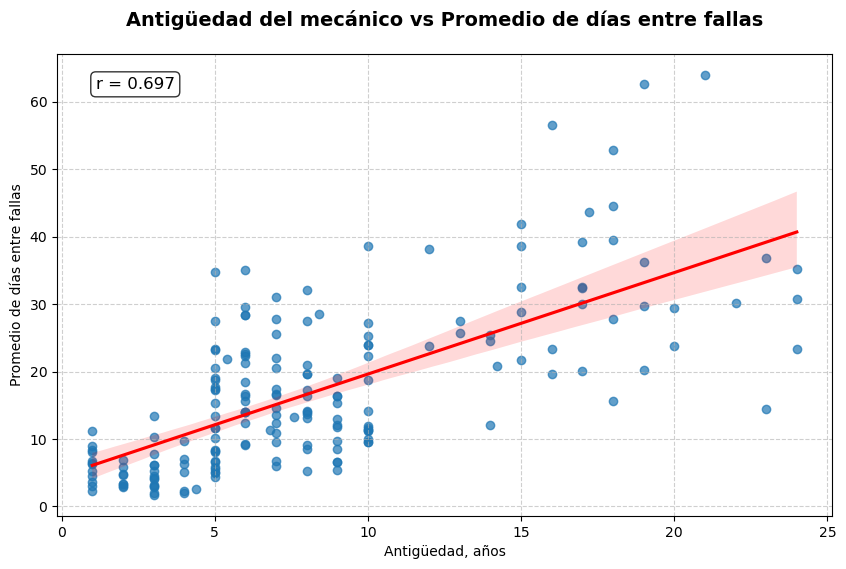

In [303]:
corr = df_mecanicos_dbfailure['antiquity'].corr(df_mecanicos_dbfailure['days_between_failures'])

plt.figure(figsize=(10,6))
sns.regplot(
    data=df_mecanicos_dbfailure,
    x='antiquity',
    y='days_between_failures',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}
)

plt.text(
    0.05, 0.95,
    f'r = {corr:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.title('Antigüedad del mecánico vs Promedio de días entre fallas', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Antigüedad, años')
plt.ylabel('Promedio de días entre fallas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Análisis de la variable **parts_cost**.

In [281]:
df['parts_cost'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
parts_cost,140602.0,13.221542,44.214643,0.0,0.0,0.0,7.43,2812.49


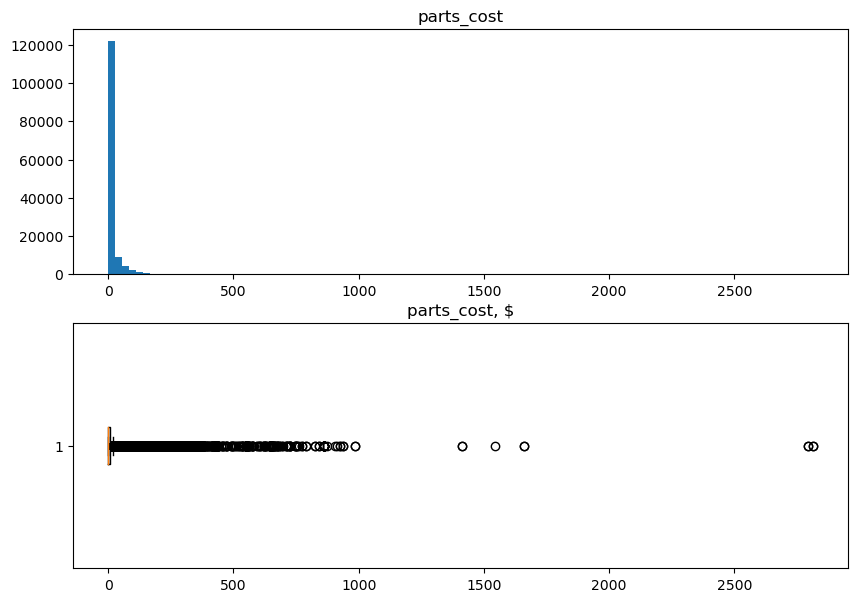

In [282]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Subplot Histograma de parts_cost
ax1.hist(df['parts_cost'], bins=100)
ax1.set_title('parts_cost')
ax1.set_xlabel('')
ax1.set_ylabel('')

# Subplot Boxplot de parts_cost
ax2.boxplot(df['parts_cost'], vert=False)
ax2.set_title('parts_cost, $')
ax2.set_xlabel('')
ax2.set_ylabel('')

plt.show()

##### Zoom de 0 a 250

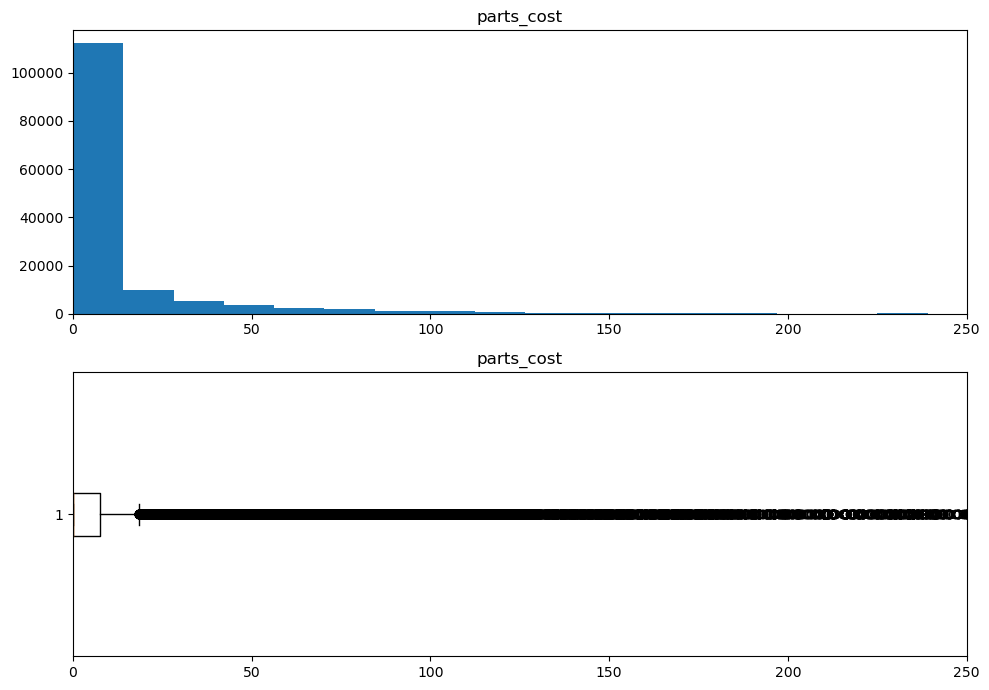

In [283]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Subplot Histograma de parts_cost
ax1.hist(df['parts_cost'], bins=200)
ax1.set_title('parts_cost')
ax1.set_xlabel('')
ax1.set_ylabel('')

# Subplot Boxplot de parts_cost
ax2.boxplot(df['parts_cost'], vert=False)
ax2.set_title('parts_cost')
ax2.set_xlabel('')
ax2.set_ylabel('')

ax1.set_xlim(0, 250) 
ax2.set_xlim(0, 250)

plt.tight_layout()
plt.show()